Python import statements 

In [1]:
import PIL.Image as image 
import numpy as np 
import matplotlib.pyplot as plt 

a)	Read a grayscale image

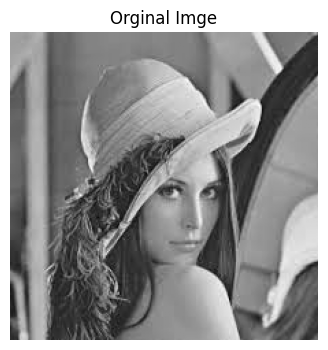

In [ ]:
img = image.open("Images/cameraman.jpg").convert("L")

plt.figure(figsize=(4, 4))
plt.imshow(img, cmap="gray")
plt.title("Orginal Imge")
plt.axis("off")
plt.show()

Image Height and Width using shape

In [8]:
img_array = np.array(img)

H, W = img_array.shape

print(f"Height * Width: {H} * {W}")

Height * Width: 225 * 225


3×3 Laplacian filter  

In [9]:
laplacian_filter = np.array([
    [0, 1, 0],
    [1, -4, 1],
    [0, 1, 0]
])

b)	Use replicate padding (edge padding) to handle boundary pixels

In [10]:
padded_img = np.pad(img_array, pad_width=1, mode="edge")

c)	Apply a 3×3 Laplacian filter to extract the edge image
d)	Generate a sharpened image using the Laplacian output


In [11]:
laplacian_edge = np.zeros_like(img_array, dtype=float)

for i in range(H):
    for j in range(W):
        region = padded_img[i : i + 3, j : j + 3]
        laplacian_edge[i, j] = np.sum(region * laplacian_filter)

sharpened = img_array - laplacian_edge

laplacian_edge = np.clip(laplacian_edge, 0, 255).astype("uint8")
sharpened = np.clip(sharpened, 0, 255).astype("uint8")

e)	Display the following images: i) Original image, ii) Laplacian edge image, iii) Laplacian sharpened image

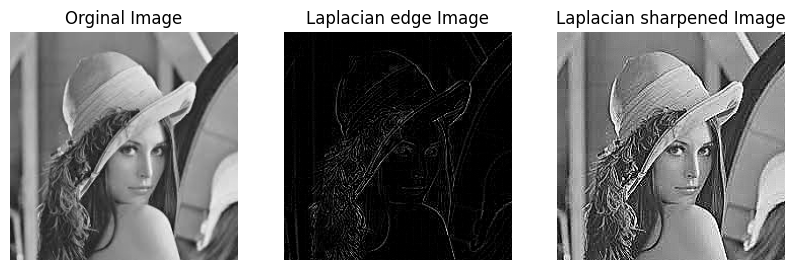

In [17]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Orginal Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(laplacian_edge, cmap="gray")
plt.title("Laplacian edge Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sharpened, cmap="gray")
plt.title("Laplacian sharpened Image")
plt.axis("off")

plt.show()

1. Filter in the horizontal direction (Gx) 
2. Filter in the vertical direction (Gy)

In [18]:
x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

y = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
])

f) Apply the Sobel filter in the horizontal direction (Gx)
g) Apply the Sobel filter in the vertical direction (Gy)
h) Compute the gradient magnitude using the Sobel outputs


In [ ]:
gx = np.zeros_like(img_array, dtype=float)
gy = np.zeros_like(img_array, dtype=float)
gradient_magnitude = np.zeros_like(img_array, dtype=float)

padded2_img = np.pad(img_array, pad_width=1, mode='constant', constant_values=0)

for i in range(H): 
    for j in range(W): 
        region = padded2_img[i : i+3, j : j+3] 
        gx[i, j] = np.sum(region * x) 
        gy[i, j] = np.sum(region * y) 

gradient_magnitude = np.sqrt(gx**2 + gy**2)

gx = np.clip(np.abs(gx), 0, 255).astype("uint8") 
gy = np.clip(np.abs(gy), 0, 255).astype("uint8") 
gradient_magnitude = np.clip(gradient_magnitude, 0, 255).astype("uint8")

i)	Display the following images: i) Sobel horizontal output (Gx), iii) Sobel vertical output (Gy), iii) Sobel gradient magnitude image

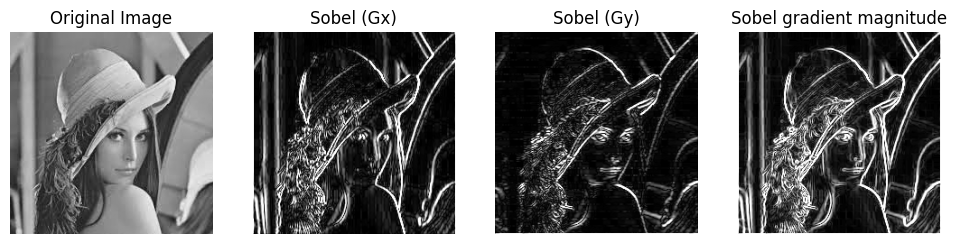

In [23]:
plt .figure(figsize=(12, 6))

plt.subplot(2, 4, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(gx, cmap='gray')
plt.title("Sobel (Gx)")
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(gy, cmap='gray')
plt.title("Sobel (Gy)")
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(gradient_magnitude,cmap='gray')
plt.title("Sobel gradient magnitude")
plt.axis('off')

plt.show() 